In [123]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as plt
df=pd.read_excel("Data_Train.xlsx")

In [124]:
df

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302
...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648


In [125]:
#basic understanding
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


In [126]:
df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

In [127]:
df.dropna(inplace=True)

In [128]:
df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              0
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        0
Additional_Info    0
Price              0
dtype: int64

In [129]:
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


<Axes: xlabel='Price'>

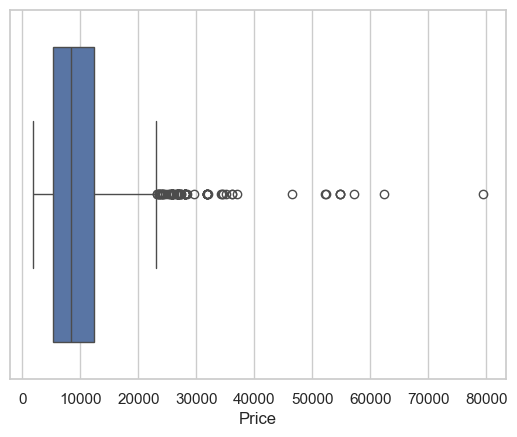

In [130]:
#outliers
sns.boxplot(x="Price",data=df)

In [131]:
df["Airline"].unique()

array(['IndiGo', 'Air India', 'Jet Airways', 'SpiceJet',
       'Multiple carriers', 'GoAir', 'Vistara', 'Air Asia',
       'Vistara Premium economy', 'Jet Airways Business',
       'Multiple carriers Premium economy', 'Trujet'], dtype=object)

In [155]:
# Group and calculate metrics
airline_stats = df.groupby('Airline')['Price'].agg(['mean', 'min', 'max', 'count'])

# Sort by Average Price to show the hierarchy
airline_stats = airline_stats.sort_values(by='mean', ascending=False).round(2)

print(airline_stats)

                                       mean    min    max  count
Airline                                                         
Jet Airways Business               58358.67  46490  79512      6
Jet Airways                        11643.92   1840  54826   3849
Multiple carriers Premium economy  11418.85   9845  14629     13
Multiple carriers                  10902.68   5797  36983   1196
Air India                           9612.43   2050  31945   1751
Vistara Premium economy             8962.33   5969  11793      3
Vistara                             7796.35   3687  21730    479
GoAir                               5861.06   3398  22794    194
IndiGo                              5673.68   2227  22153   2053
Air Asia                            5590.26   3383  13774    319
SpiceJet                            4338.28   1759  23267    818
Trujet                              4140.00   4140   4140      1


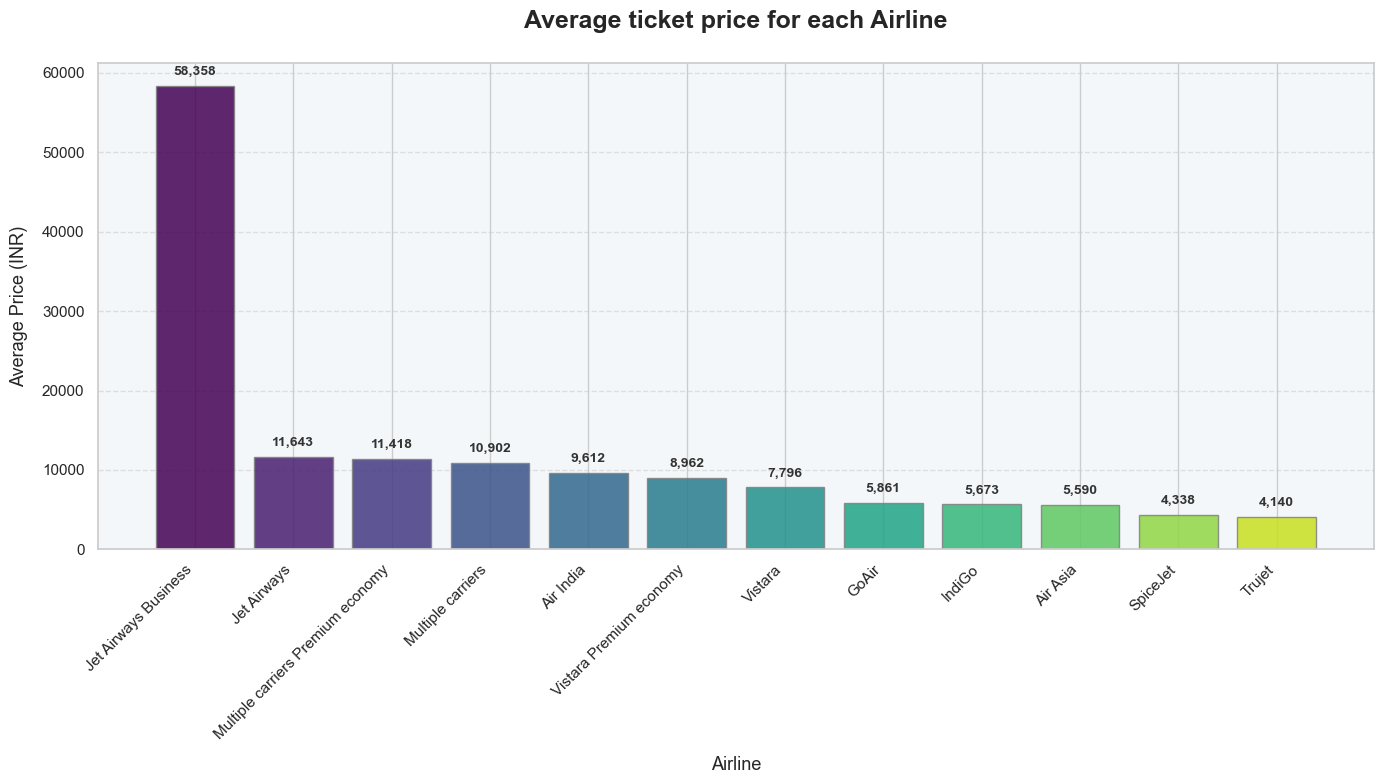

In [201]:
# Average ticket price by airline
airline_stats = df.groupby('Airline')['Price'].agg(['mean', 'min', 'max', 'count'])
airline_stats = airline_stats.sort_values(by='mean', ascending=False).round(2)


airlines = airline_stats.index
mean_prices = airline_stats['mean']


plt.figure(figsize=(14, 8))


colors = [plt.cm.viridis(i/len(airlines)) for i in range(len(airlines))]


bars = plt.bar(airlines, mean_prices, color=colors, edgecolor='grey', alpha=0.85)


plt.title('Average ticket price for each Airline', fontsize=18, fontweight='bold', pad=25)
plt.ylabel('Average Price (INR)', fontsize=13, labelpad=10)
plt.xlabel('Airline', fontsize=13, labelpad=10)


plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)


plt.grid(axis='y', linestyle='--', alpha=0.6)


for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1000, 
             f'{int(yval):,}', 
             ha='center', va='bottom', fontsize=10, fontweight='bold', color='#333333')


plt.tight_layout()


plt.savefig('pleasant_airline_chart.png')
plt.show()

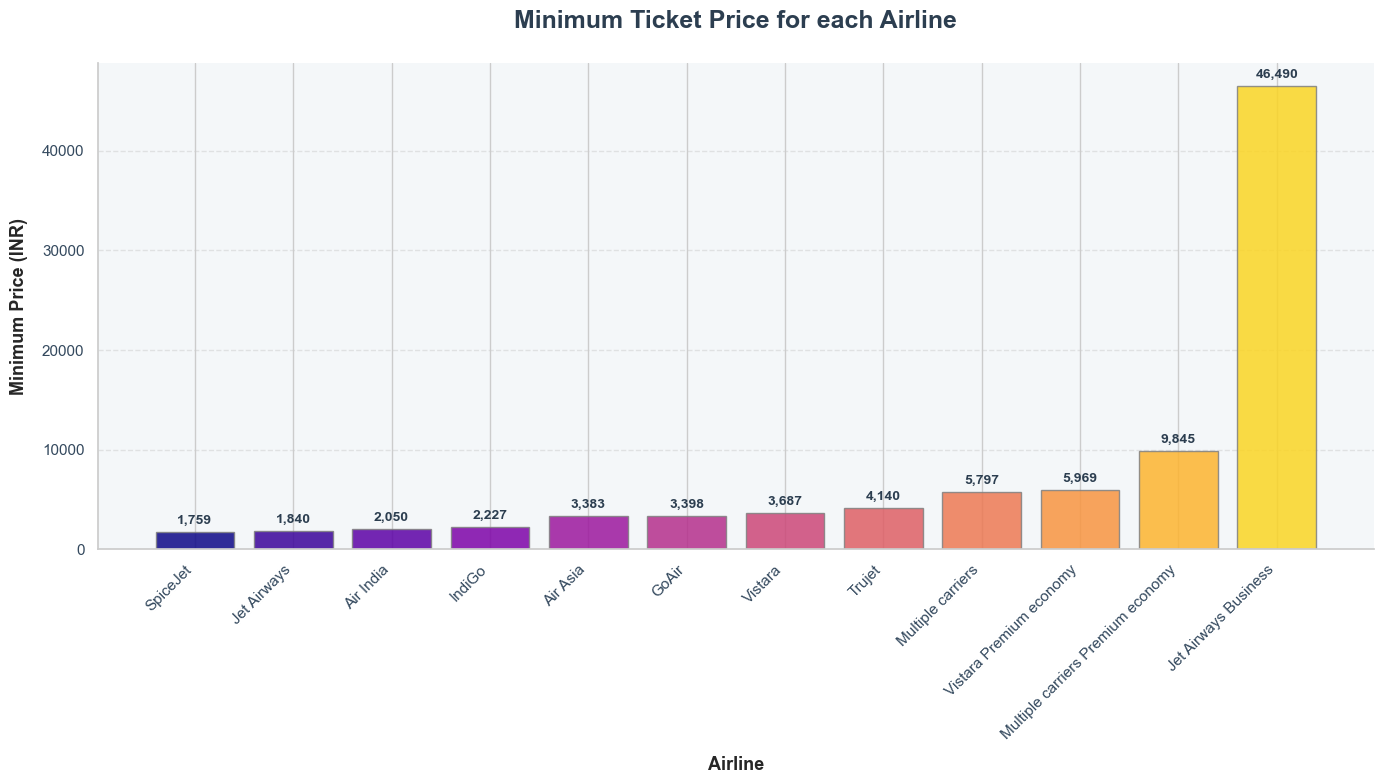

In [202]:
# Minimum ticket price by airline
min_prices = df.groupby('Airline')['Price'].min().sort_values(ascending=True)


plt.figure(figsize=(14, 8))


colors = [plt.cm.plasma(i/len(min_prices)) for i in range(len(min_prices))]


bars = plt.bar(min_prices.index, min_prices.values, color=colors, edgecolor='grey', alpha=0.85)


plt.title('Minimum Ticket Price for each Airline', fontsize=18, fontweight='bold', pad=25, color='#2c3e50')
plt.ylabel('Minimum Price (INR)', fontsize=13, labelpad=10, fontweight='semibold')
plt.xlabel('Airline', fontsize=13, labelpad=10, fontweight='semibold')


plt.xticks(rotation=45, ha='right', fontsize=11, color='#34495e')
plt.yticks(fontsize=11, color='#34495e')


plt.grid(axis='y', linestyle='--', alpha=0.5)


for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 500, 
             f'{int(yval):,}', 
             ha='center', va='bottom', fontsize=10, fontweight='bold', color='#2c3e50')


plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)


plt.tight_layout()


plt.savefig('min_price_by_airline.png')

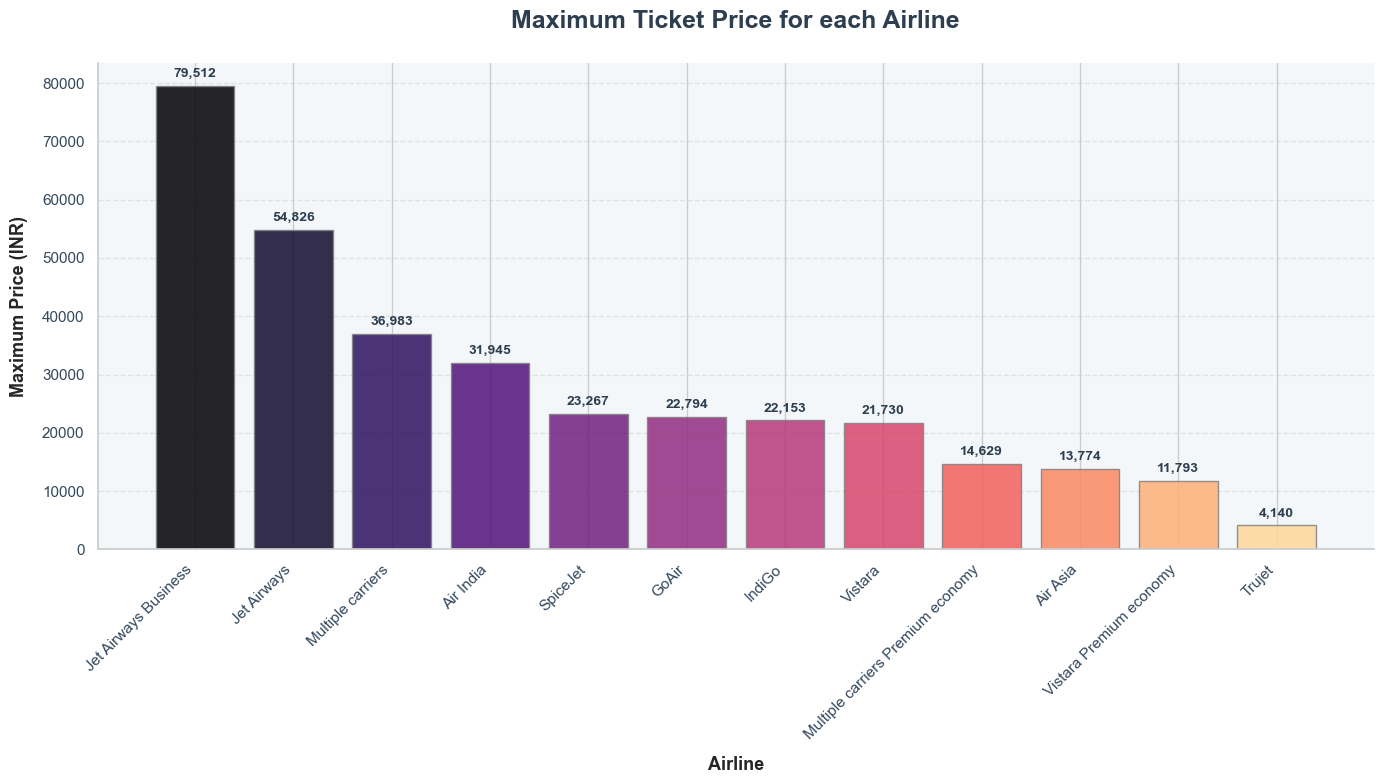

In [203]:
# Maximum ticket price by airline
max_prices = df.groupby('Airline')['Price'].max().sort_values(ascending=False)


plt.figure(figsize=(14, 8))


colors = [plt.cm.magma(i/len(max_prices)) for i in range(len(max_prices))]


bars = plt.bar(max_prices.index, max_prices.values, color=colors, edgecolor='grey', alpha=0.85)


plt.title('Maximum Ticket Price for each Airline', fontsize=18, fontweight='bold', pad=25, color='#2c3e50')
plt.ylabel('Maximum Price (INR)', fontsize=13, labelpad=10, fontweight='semibold')
plt.xlabel('Airline', fontsize=13, labelpad=10, fontweight='semibold')


plt.xticks(rotation=45, ha='right', fontsize=11, color='#34495e')
plt.yticks(fontsize=11, color='#34495e')


plt.grid(axis='y', linestyle='--', alpha=0.5)


for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1000, 
             f'{int(yval):,}', 
             ha='center', va='bottom', fontsize=10, fontweight='bold', color='#2c3e50')


plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)


plt.tight_layout()


plt.savefig('max_price_by_airline.png')

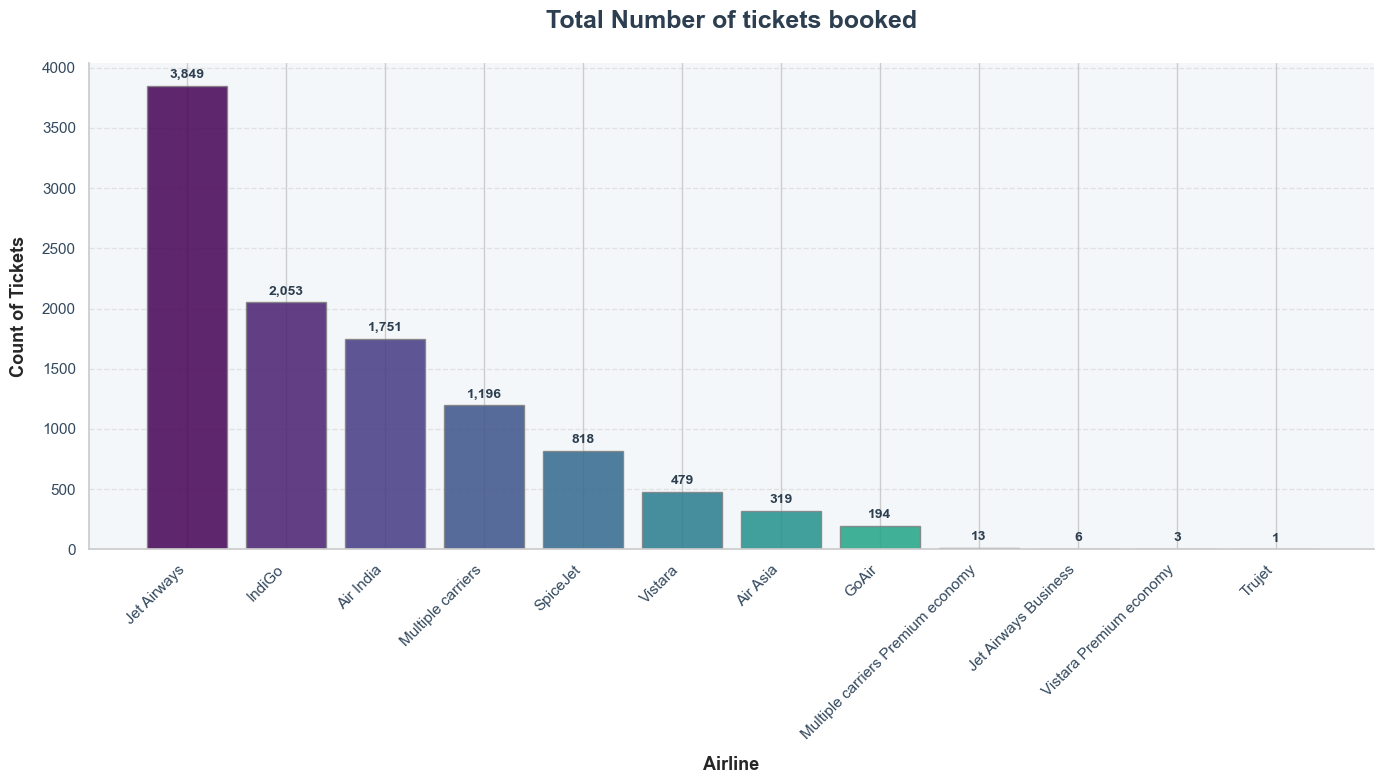

In [205]:
# Total Number of ticket booked by airline
airline_counts = df['Airline'].value_counts()


plt.figure(figsize=(14, 8))


colors = [plt.cm.viridis(i/len(airline_counts)) for i in range(len(airline_counts))]


bars = plt.bar(airline_counts.index, airline_counts.values, color=colors, edgecolor='grey', alpha=0.85)


plt.title('Total Number of tickets booked', fontsize=18, fontweight='bold', pad=25, color='#2c3e50')
plt.ylabel('Count of Tickets', fontsize=13, labelpad=10, fontweight='semibold')
plt.xlabel('Airline', fontsize=13, labelpad=10, fontweight='semibold')


plt.xticks(rotation=45, ha='right', fontsize=11, color='#34495e')
plt.yticks(fontsize=11, color='#34495e')


plt.grid(axis='y', linestyle='--', alpha=0.5)


for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + (max(airline_counts.values)*0.01), 
             f'{int(yval):,}', 
             ha='center', va='bottom', fontsize=10, fontweight='bold', color='#2c3e50')


plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)


plt.tight_layout()


plt.savefig('flight_count_by_airline.png')

In [160]:
# Calculate the average price by departure city (Source) and sort in descending order
average_prices = df.groupby("Source")["Price"].mean().sort_values(ascending=False).reset_index()

# Rename columns for clear presentation
average_prices.columns = ["Departure City", "Average Price (INR)"]


print(average_prices)

  Departure City  Average Price (INR)
0          Delhi         10540.113536
1        Kolkata          9158.389411
2       Banglore          8017.464269
3         Mumbai          5059.708752
4        Chennai          4789.892388


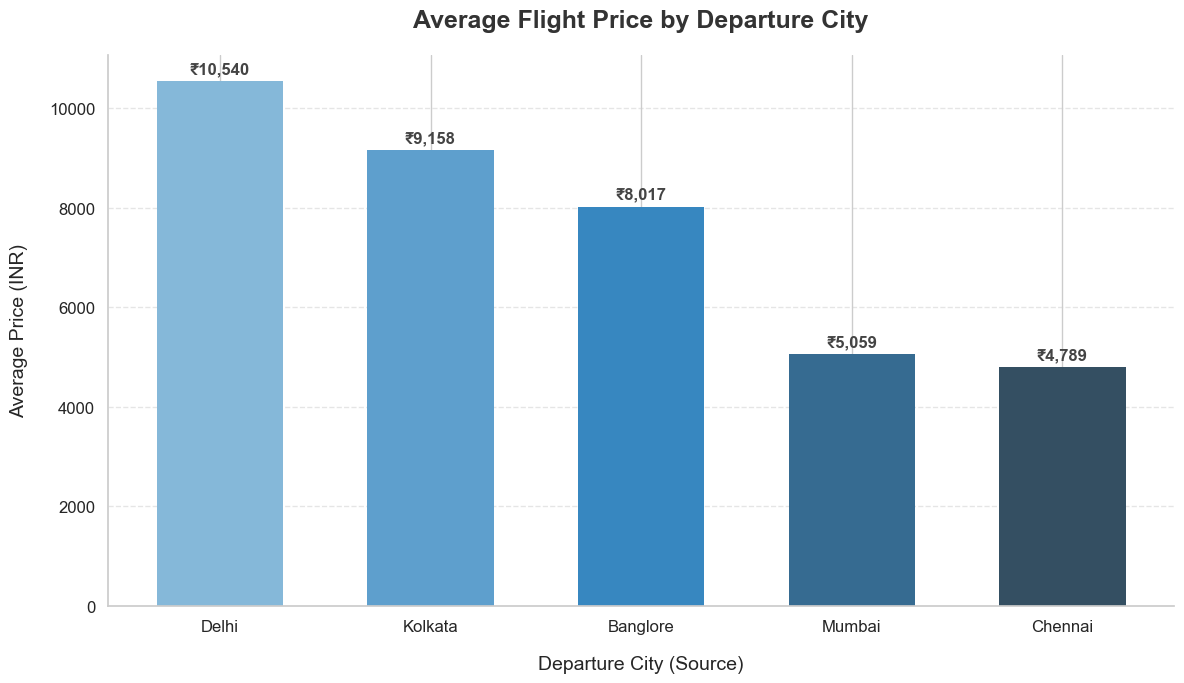

In [161]:
# Calculate the average price by Source city and sort values descending
source_avg_price = df.groupby('Source')['Price'].mean().sort_values(ascending=False).reset_index()


sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 7))


colors = sns.color_palette("Blues_d", n_colors=len(source_avg_price))


bars = plt.bar(source_avg_price['Source'], source_avg_price['Price'], 
               color=colors, edgecolor='none', width=0.6)


plt.title('Average Flight Price by Departure City', fontsize=18, fontweight='bold', pad=20, color='#333333')
plt.xlabel('Departure City (Source)', fontsize=14, labelpad=15)
plt.ylabel('Average Price (INR)', fontsize=14, labelpad=15)


for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 100,
             f'₹{int(height):,}', 
             ha='center', va='bottom', fontsize=12, fontweight='bold', color='#444444')


plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_color('#cccccc')
plt.gca().spines['bottom'].set_color('#cccccc')
plt.grid(axis='y', linestyle='--', alpha=0.5)


plt.tight_layout()
plt.savefig('corporate_avg_price_by_source.png', dpi=300)

In [162]:
# Calculate the market share (percentage of total bookings)

market_share = (df["Airline"].value_counts(normalize=True) * 100).reset_index()

# Rename columns for clarity
market_share.columns = ["Airline", "Market Share (%)"]

print(market_share)

                              Airline  Market Share (%)
0                         Jet Airways         36.032578
1                              IndiGo         19.219247
2                           Air India         16.392061
3                   Multiple carriers         11.196405
4                            SpiceJet          7.657742
5                             Vistara          4.484179
6                            Air Asia          2.986332
7                               GoAir          1.816139
8   Multiple carriers Premium economy          0.121700
9                Jet Airways Business          0.056169
10            Vistara Premium economy          0.028085
11                             Trujet          0.009362


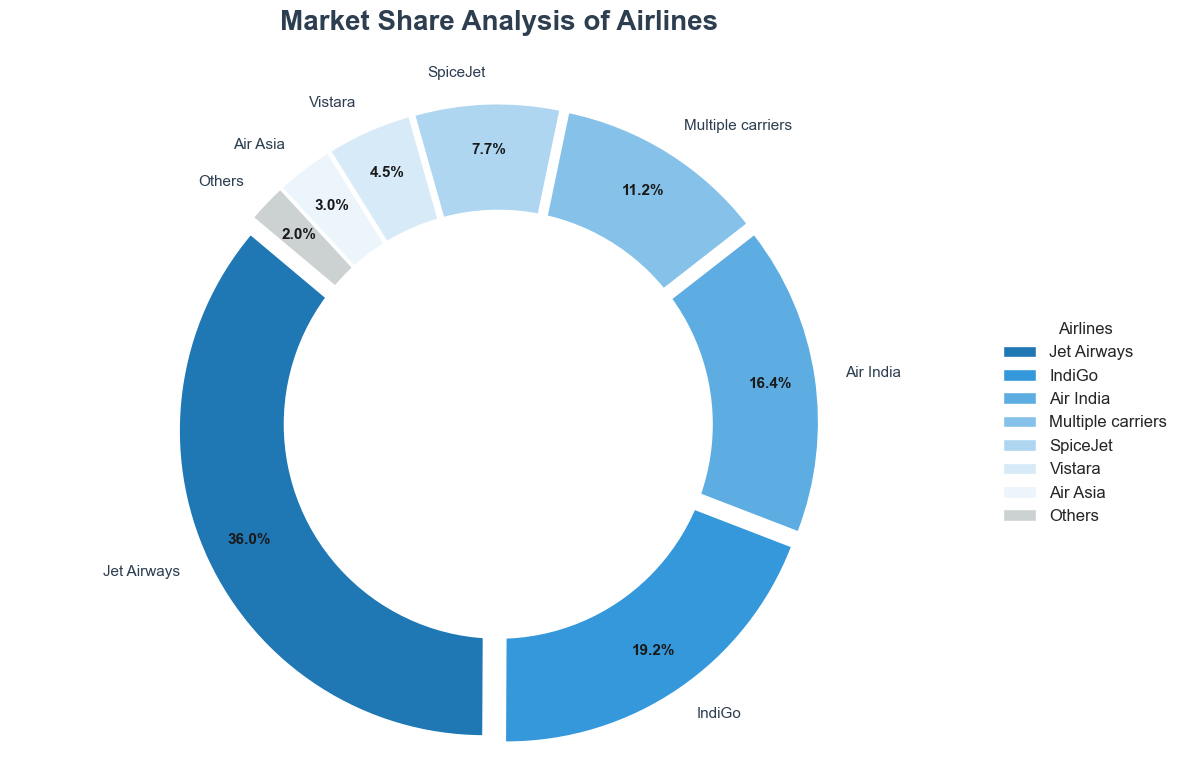

In [163]:
# 2. Prepare Data: Count bookings per airline
airline_counts = df['Airline'].value_counts()
total = airline_counts.sum()


threshold = 0.02 * total
major_airlines = airline_counts[airline_counts >= threshold]
minor_airlines_sum = airline_counts[airline_counts < threshold].sum()


plot_data = major_airlines.copy()
if minor_airlines_sum > 0:
    plot_data['Others'] = minor_airlines_sum


corporate_colors = ['#1f77b4', '#3498db', '#5dade2', '#85c1e9', '#aed6f1', '#d6eaf8', '#ebf5fb', '#ccd1d1']


plt.figure(figsize=(12, 8))


wedges, texts, autotexts = plt.pie(
    plot_data, 
    labels=plot_data.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=corporate_colors, 
    pctdistance=0.85, 
    explode=[0.05] * len(plot_data), # Subtle separation for a modern look
    textprops={'fontsize': 11, 'fontweight': 'medium', 'color': '#2c3e50'}
)


centre_circle = plt.Circle((0,0), 0.70, fc='white', linewidth=1.25)
fig = plt.gcf()
fig.gca().add_artist(centre_circle)


for autotext in autotexts:
    autotext.set_color('#1a1a1a')
    autotext.set_weight('bold')


plt.title('Market Share Analysis of Airlines', 
          fontsize=20, fontweight='bold', pad=30, color='#2c3e50')


plt.legend(wedges, plot_data.index,
          title="Airlines",
          loc="center left",
          bbox_to_anchor=(1, 0, 0.5, 1),
          fontsize=12,
          frameon=False)


plt.axis('equal')  


plt.tight_layout()
plt.savefig('corporate_airline_market_share.png', dpi=300, bbox_inches='tight')
plt.show()

In [164]:
df

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302
...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648


In [176]:
#added month column to find average flight price for each month
df["Month"]=df["Date_of_Journey"].dt.month_name()

In [195]:
df

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Month,Days,Day_of_Week
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897,March,Sunday,Sunday
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662,May,Wednesday,Wednesday
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882,June,Sunday,Sunday
3,IndiGo,2019-05-12,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218,May,Sunday,Sunday
4,IndiGo,2019-03-01,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302,March,Friday,Friday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,2019-04-09,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107,April,Tuesday,Tuesday
10679,Air India,2019-04-27,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145,April,Saturday,Saturday
10680,Jet Airways,2019-04-27,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229,April,Saturday,Saturday
10681,Vistara,2019-03-01,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648,March,Friday,Friday


In [178]:
df["Month"].unique()

array(['March', 'May', 'June', 'April'], dtype=object)

In [179]:
# 4. Calculate the average price per Month

month_order = ["March", "April", "May", "June"]
monthly_avg = df.groupby("Month")["Price"].mean().reindex(month_order).reset_index()

# rename columns for a clean presentation
monthly_avg.columns = ["Month", "Average Price (INR)"]

print(monthly_avg)

   Month  Average Price (INR)
0  March         10673.205580
1  April          5770.847081
2    May          9127.722944
3   June          8828.796134


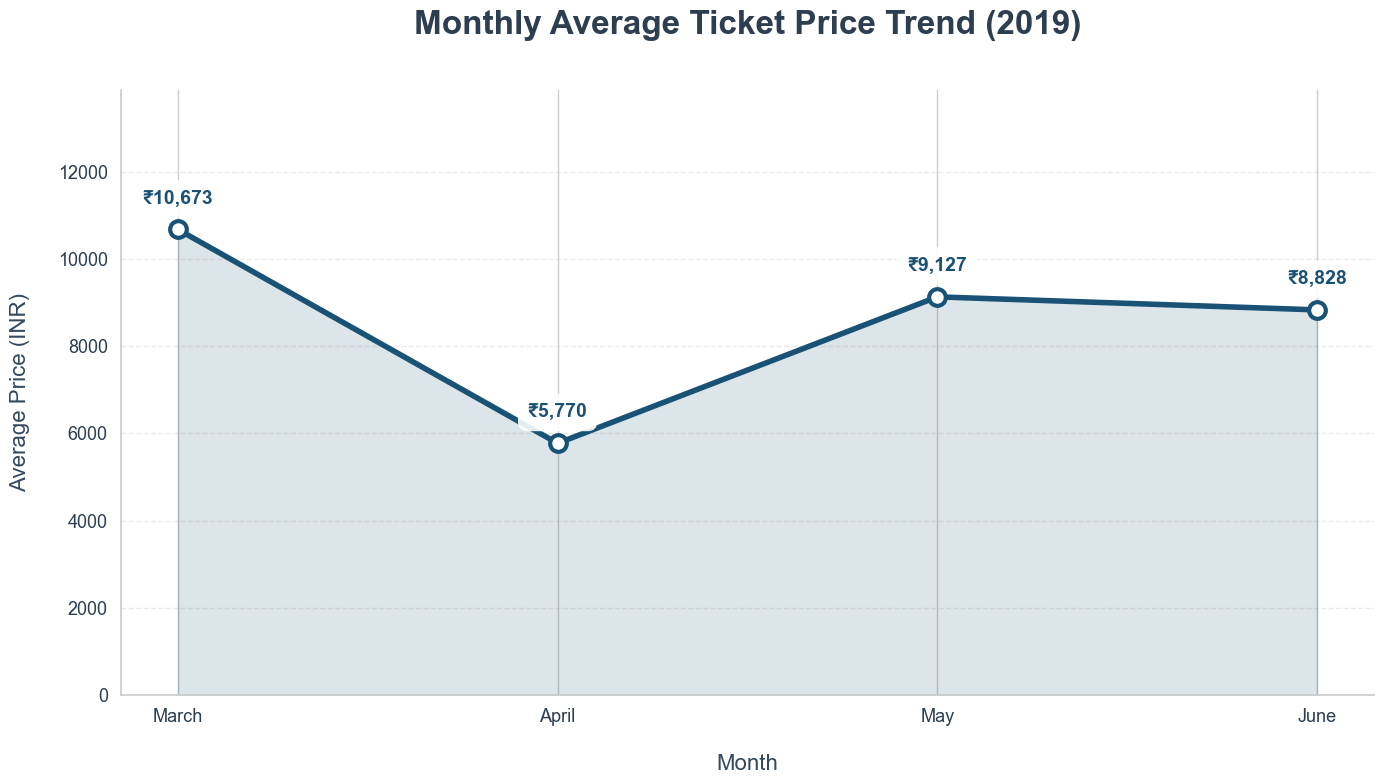

In [180]:
# Monthly average ticket price for 2019
df['Date_of_Journey'] = pd.to_datetime(df['Date_of_Journey'], dayfirst=True)
df['Month'] = df['Date_of_Journey'].dt.strftime('%B')
month_order = ['March', 'April', 'May', 'June']
monthly_avg = df.groupby('Month')['Price'].mean().reindex(month_order).reset_index()


sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 8))


plt.plot(monthly_avg['Month'], monthly_avg['Price'], 
         marker='o', markersize=12, markerfacecolor='#ffffff', 
         markeredgewidth=3, linestyle='-', linewidth=4, color='#1a5276')


plt.fill_between(monthly_avg['Month'], monthly_avg['Price'], color='#1a5276', alpha=0.15)


plt.title('Monthly Average Ticket Price Trend (2019)', 
          fontsize=24, fontweight='bold', pad=40, color='#2c3e50')
plt.xlabel('Month', fontsize=16, fontweight='medium', labelpad=20, color='#34495e')
plt.ylabel('Average Price (INR)', fontsize=16, fontweight='medium', labelpad=20, color='#34495e')


for i, price in enumerate(monthly_avg['Price']):
    plt.text(i, price + 500, f'₹{int(price):,}', 
             ha='center', va='bottom', fontsize=14, fontweight='bold', color='#1a5276',
             bbox=dict(facecolor='white', alpha=0.9, edgecolor='none', boxstyle='round,pad=0.5'))


plt.xticks(fontsize=13, fontweight='medium', color='#2c3e50')
plt.yticks(fontsize=13, color='#2c3e50')
plt.ylim(0, max(monthly_avg['Price']) * 1.3) # Extra space for labels


plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_color('#cccccc')
plt.gca().spines['bottom'].set_color('#cccccc')
plt.grid(axis='y', linestyle='--', alpha=0.4)


plt.tight_layout()
plt.savefig('corporate_monthly_price_trend.png', dpi=300)
plt.show()

In [181]:
df["Days"]=df["Date_of_Journey"].dt.day_name()

In [200]:
df

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Month,Day_of_Week
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897,March,Sunday
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662,May,Wednesday
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882,June,Sunday
3,IndiGo,2019-05-12,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218,May,Sunday
4,IndiGo,2019-03-01,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302,March,Friday
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,2019-04-09,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107,April,Tuesday
10679,Air India,2019-04-27,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145,April,Saturday
10680,Jet Airways,2019-04-27,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229,April,Saturday
10681,Vistara,2019-03-01,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648,March,Friday


In [183]:
# finding the average ticket price per day of week
df['Date_of_Journey'] = pd.to_datetime(df['Date_of_Journey'], dayfirst=True)
df['Day_of_Week'] = df['Date_of_Journey'].dt.day_name()


day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_avg = df.groupby('Day_of_Week')['Price'].mean().reindex(day_order).reset_index()

print("Average Ticket Price by Day of the Week:")
print(weekday_avg)

Average Ticket Price by Day of the Week:
  Day_of_Week        Price
0      Monday  8500.082207
1     Tuesday  9026.149597
2   Wednesday  9277.514190
3    Thursday  8931.379367
4      Friday  9717.996700
5    Saturday  8972.905389
6      Sunday  9525.508820


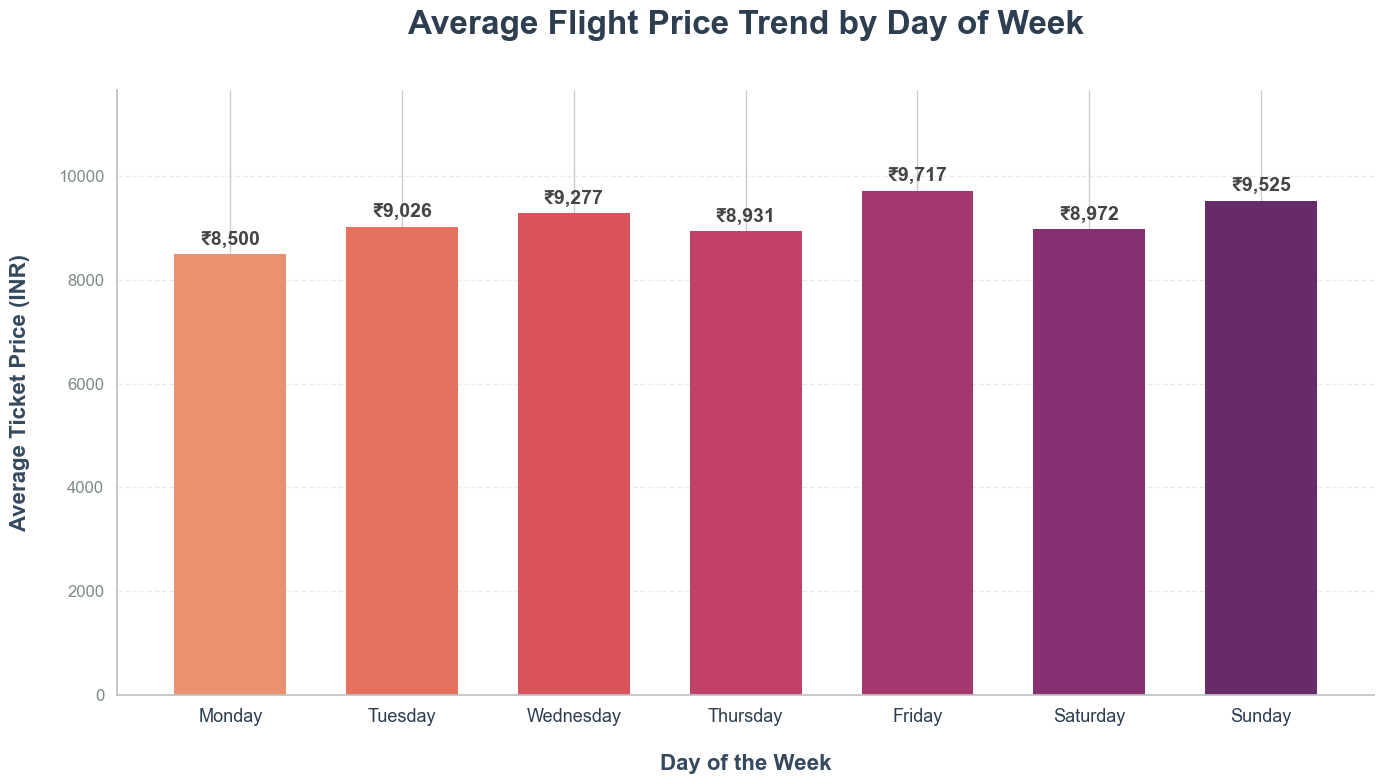

In [184]:
# Average ticket price per day of week chart
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 8))


colors = sns.color_palette("flare", n_colors=len(weekday_avg))


bars = plt.bar(weekday_avg['Day_of_Week'], weekday_avg['Price'], 
               color=colors, edgecolor='none', width=0.65)


plt.title('Average Flight Price Trend by Day of Week', 
          fontsize=24, fontweight='bold', pad=40, color='#2c3e50', loc='center')
plt.xlabel('Day of the Week', fontsize=16, fontweight='semibold', labelpad=20, color='#34495e')
plt.ylabel('Average Ticket Price (INR)', fontsize=16, fontweight='semibold', labelpad=20, color='#34495e')


for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 100,
             f'₹{int(height):,}', 
             ha='center', va='bottom', fontsize=14, fontweight='bold', color='#444444')


plt.xticks(fontsize=13, fontweight='medium', color='#2c3e50')
plt.yticks(fontsize=12, color='#7f8c8d')
plt.ylim(0, max(weekday_avg['Price']) * 1.2) 


plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_color('#bdc3c7')
plt.gca().spines['bottom'].set_color('#bdc3c7')
plt.grid(axis='y', linestyle='--', alpha=0.4)


plt.tight_layout()
plt.savefig('corporate_average_price_trend.png', dpi=300)
plt.show()

In [198]:
if "MONTH" in df.columns:
    df.drop(columns=["MONTH"], inplace=True)

In [199]:
df

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Month,Day_of_Week
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897,March,Sunday
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662,May,Wednesday
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882,June,Sunday
3,IndiGo,2019-05-12,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218,May,Sunday
4,IndiGo,2019-03-01,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302,March,Friday
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,2019-04-09,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107,April,Tuesday
10679,Air India,2019-04-27,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145,April,Saturday
10680,Jet Airways,2019-04-27,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229,April,Saturday
10681,Vistara,2019-03-01,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648,March,Friday


In [187]:
# Group and calculate metrics
airline_stats = df.groupby("Airline")["Price"].agg(["sum"])

# Sort by total Price to show the hierarchy
airline_stats = airline_stats.sort_values(by="sum", ascending=False).round()

print(airline_stats)

                                        sum
Airline                                    
Jet Airways                        44817461
Air India                          16831361
Multiple carriers                  13039603
IndiGo                             11648071
Vistara                             3734451
SpiceJet                            3548717
Air Asia                            1783293
GoAir                               1137045
Jet Airways Business                 350152
Multiple carriers Premium economy    148445
Vistara Premium economy               26887
Trujet                                 4140


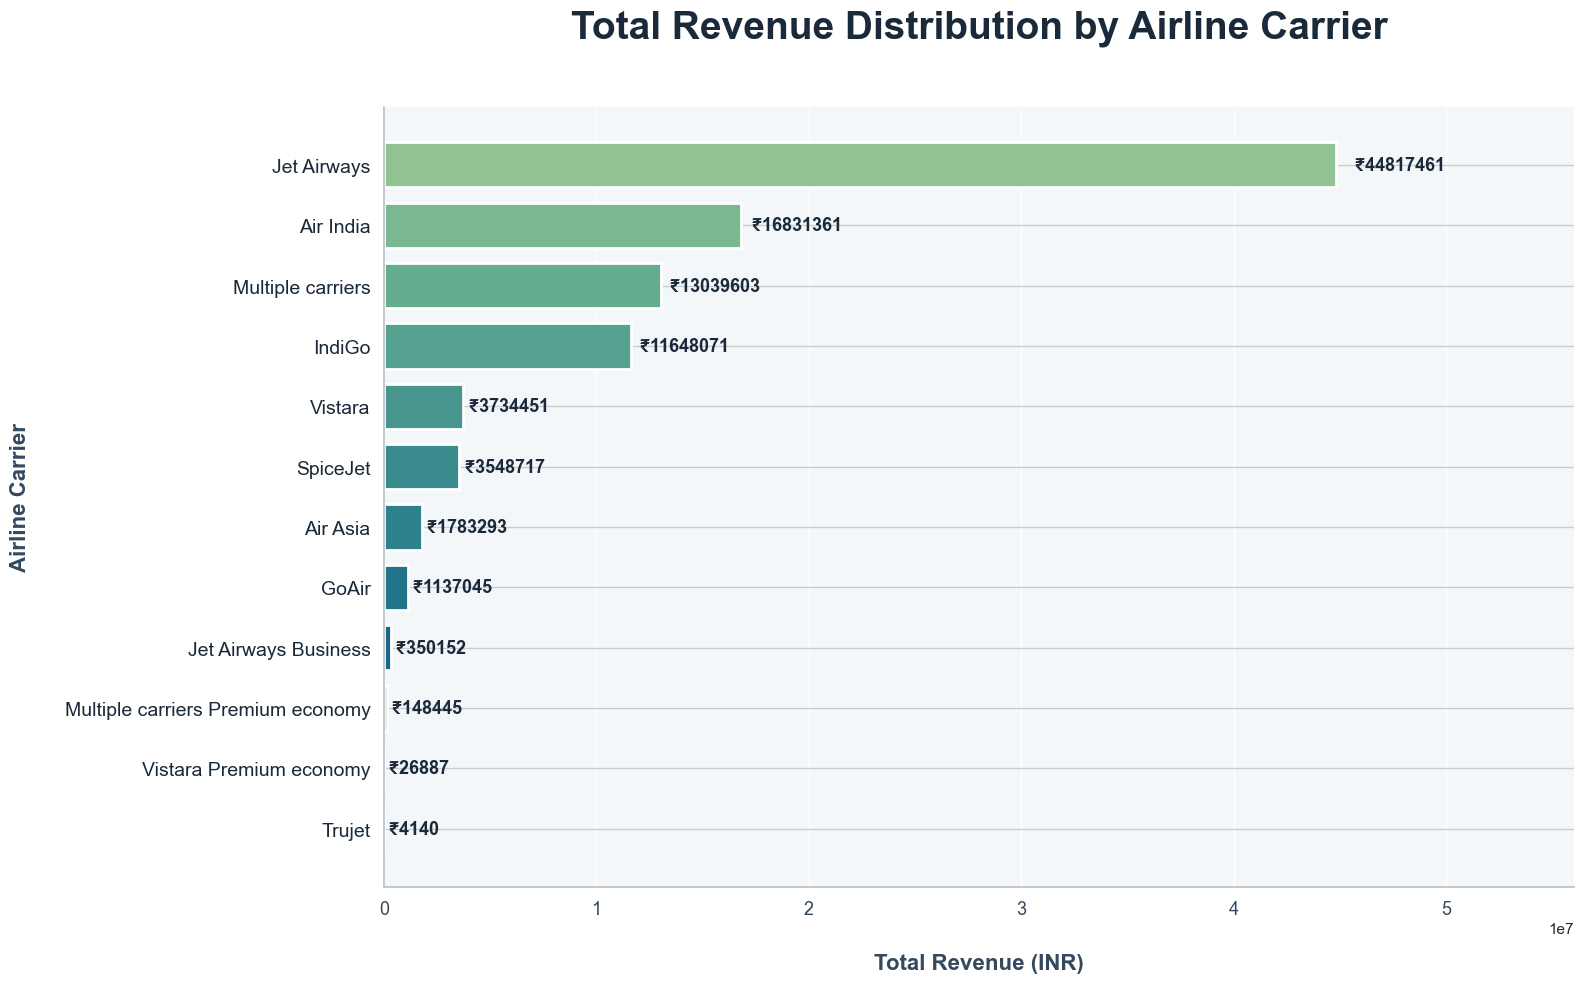

In [194]:
# Total revenue by each airline
airline_stats = df.groupby("Airline")["Price"].agg(["sum"])


airline_stats = airline_stats.sort_values(by="sum", ascending=False).round().reset_index()


plt.figure(figsize=(16, 10))
ax = plt.gca()


ax.set_facecolor('#f4f7f9') 
plt.rcParams['axes.facecolor'] = '#f4f7f9'


colors = sns.color_palette("crest", n_colors=len(airline_stats))


bars = plt.barh(airline_stats['Airline'], airline_stats['sum'], 
                color=colors, edgecolor='white', linewidth=2, height=0.75)


plt.title('Total Revenue Distribution by Airline Carrier', 
          fontsize=28, fontweight='bold', pad=50, color='#1a2a3a', loc='center')
plt.xlabel('Total Revenue (INR)', fontsize=16, fontweight='bold', labelpad=25, color='#34495e')
plt.ylabel('Airline Carrier', fontsize=16, fontweight='bold', labelpad=25, color='#34495e')


for bar in bars:
    width = bar.get_width()
    plt.text(width + (width * 0.015), bar.get_y() + bar.get_height()/2.,
             f' ₹{int(width)}', 
             va='center', ha='left', fontsize=13, fontweight='bold', color='#1a2a3a')


plt.xticks(fontsize=13, color='#34495e')
plt.yticks(fontsize=14, fontweight='medium', color='#1a2a3a')


plt.xlim(0, max(airline_stats['sum']) * 1.25) 


ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_color('#bdc3c7')
ax.spines['left'].set_color('#bdc3c7')


plt.grid(axis='x', linestyle='-', color='white', alpha=0.9)


plt.gca().invert_yaxis()


plt.tight_layout()
plt.savefig('corporate_airline_revenue_no_commas.png', dpi=350)
plt.show()

In [1]:
#summary
# in my dataset i have analysed that ticket price keeps changing according to the season and different airline class like economic, premium and business
# the tickect price also varry due to different airline brand
# because the quality and service differes
# and it also changes according to ticket demand, season and departure city
# as we can see that high ticket price and high revenue was made by jet airways, air india, multiple carrier and indigo.